In [1]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
import numpy as np

In [2]:

# Crear conexión a base de datos SQLite
engine = create_engine('sqlite:////Users/sruiz.gomez/Maestria/AprendizajeAutomatico/data_accidentes.sqlite3')


# 4. Tareas a desarrollar
## 4.1 Analisis exploratorio de los datos

### EDA Tabla *raw_accidentes*

In [3]:
raw_accidentes = pd.read_sql('SELECT * FROM raw_accidentes', con=engine, parse_dates=['TW'])

In [4]:
raw_accidentes.head()

,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,...,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.570146,6.233985,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,...,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,None,8,2017-07-20 08:00:00
1,-75.600280,6.238844,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,...,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,None,16,2017-06-15 16:00:00
2,-75.584306,6.285074,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,...,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,None,16,2017-07-02 16:00:00
3,-75.583062,6.239497,504355,1576853,06:29 PM,MIERCOLES,2017,Choque,CL 33 Norte CR 65,CL 033 065 000 00000,...,SOLO DAÑOS,losconquistadores,Laureles Estadio,Tramo de via,3,29,2017-03-29,None,18,2017-03-29 18:00:00
4,-75.590193,6.260463,504356,1591283,08:10 PM,MIERCOLES,2017,Atropello,CL 50 CR 74,CL 050 074 000 00000,...,HERIDO,cuartabrigada,Laureles Estadio,Tramo de via,7,26,2017-07-26,None,20,2017-07-26 20:00:00


In [5]:
raw_accidentes.columns

Index(['Lon', 'Lat', 'OBJECTID', 'RADICADO', 'HORA', 'Dia_sem', 'PERIODO',
       'CLASE', 'DIRECCION', 'DIRECCION_ENC', 'CBML', 'TIPO_GEOCOD',
       'GRAVEDAD', 'BARRIO', 'COMUNA', 'DISENO', 'Mes', 'Dia', 'FECHA',
       'MES_NOMBRE', 'Hora_num', 'TW'],
      dtype='object')

Lo que mas nos interesa en este momento es el momento y lugar del accidente, por lo que se va tomar en cuenta las variables que indiquen ubicación y momento del accidente.

#### Distribución temporal: accidentes por hora del día, día de la semana, mes

In [6]:
raw_accidentes[['Hora_num','Dia_sem','Mes']].isna().sum()

Hora_num    0
Dia_sem     0
Mes         0
dtype: int64

In [7]:
raw_accidentes['Hora_num'] = raw_accidentes['Hora_num'].astype(int)

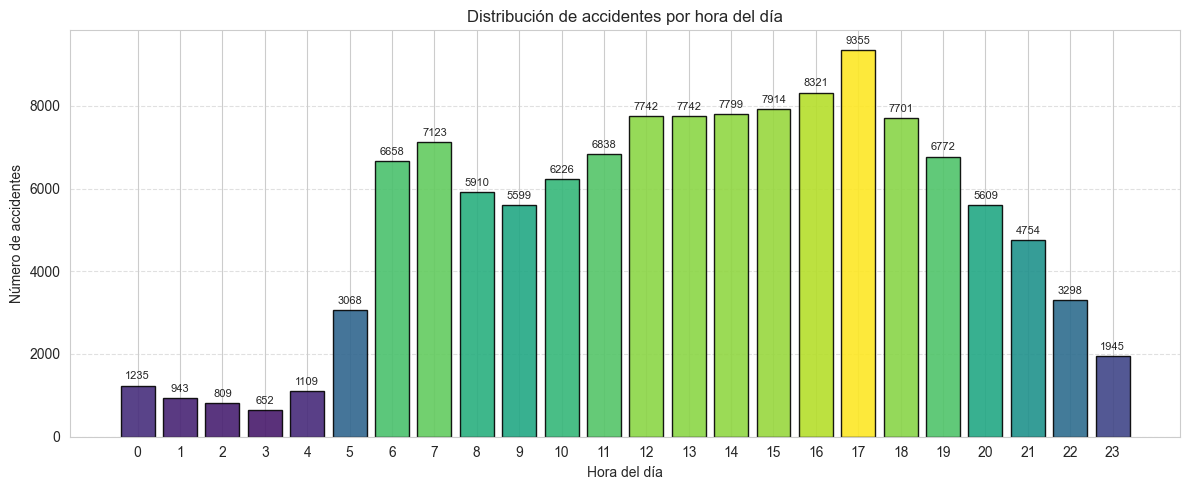

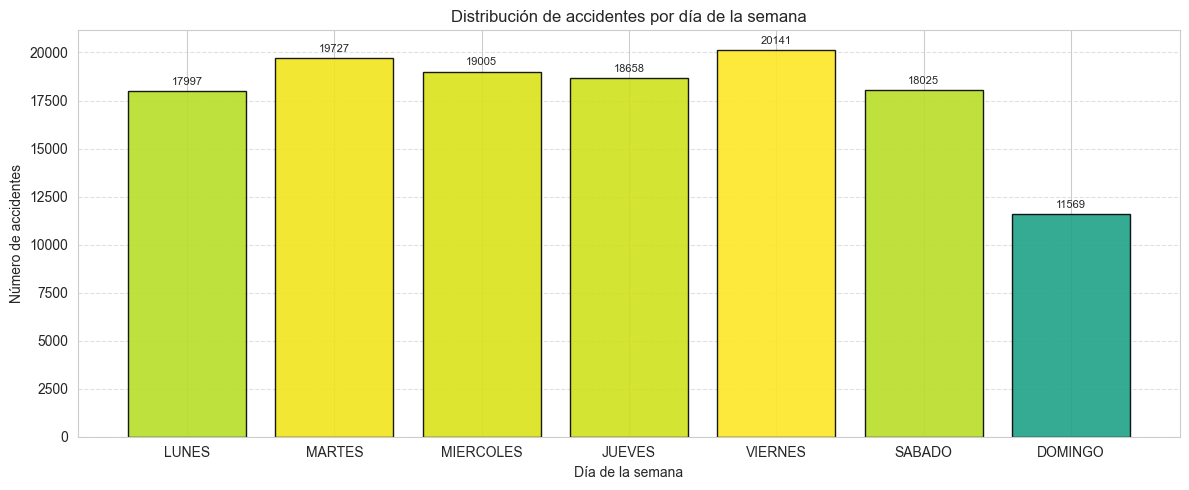

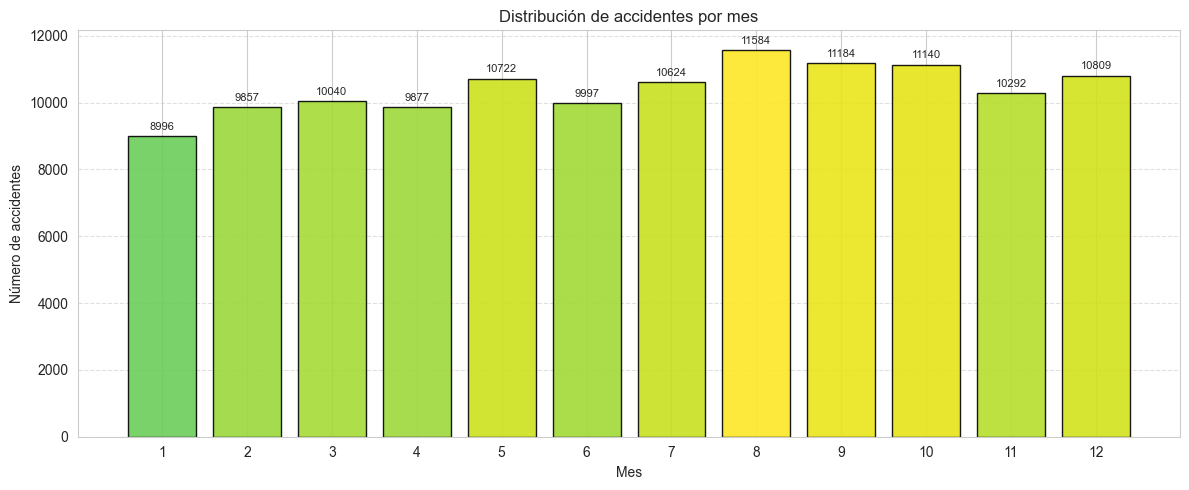

In [8]:
def plot_distribucion(df, columna, titulo, xlabel, orden=None, figsize=(12, 5)):
    counts = df[columna].value_counts()

    if orden is not None:
        counts = counts.reindex(orden, fill_value=0)
    else:
        counts = counts.sort_index()

    sns.set_style('whitegrid')
    plt.figure(figsize=figsize)

    colores = plt.cm.viridis(counts.values / counts.values.max())
    bars = plt.bar(counts.index.astype(str), counts.values, color=colores, edgecolor='black', alpha=0.9)

    plt.xlabel(xlabel)
    plt.ylabel('Número de accidentes')
    plt.title(titulo)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    for b in bars:
        h = b.get_height()
        plt.annotate(
            f'{int(h)}',
            xy=(b.get_x() + b.get_width() / 2, h),
            xytext=(0, 3),
            textcoords='offset points',
            ha='center',
            va='bottom',
            fontsize=8
        )

    plt.tight_layout()
    plt.show()


# Orden lógico de los días
orden_dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'DOMINGO']

# Gráfica para hora del día
plot_distribucion(
    raw_accidentes,
    columna='Hora_num',
    titulo='Distribución de accidentes por hora del día',
    xlabel='Hora del día',
    orden=list(range(0, 24))
)

# Gráfica para día de la semana
plot_distribucion(
    raw_accidentes,
    columna='Dia_sem',
    titulo='Distribución de accidentes por día de la semana',
    xlabel='Día de la semana',
    orden=orden_dias
)

# Gráfica para mes
plot_distribucion(
    raw_accidentes,
    columna='Mes',
    titulo='Distribución de accidentes por mes',
    xlabel='Mes',
    orden=list(range(1, 13))
)

#### Densidad de accidentes

In [9]:
raw_accidentes[['Lon', 'Lat']].isna().sum()

Lon    0
Lat    0
dtype: int64

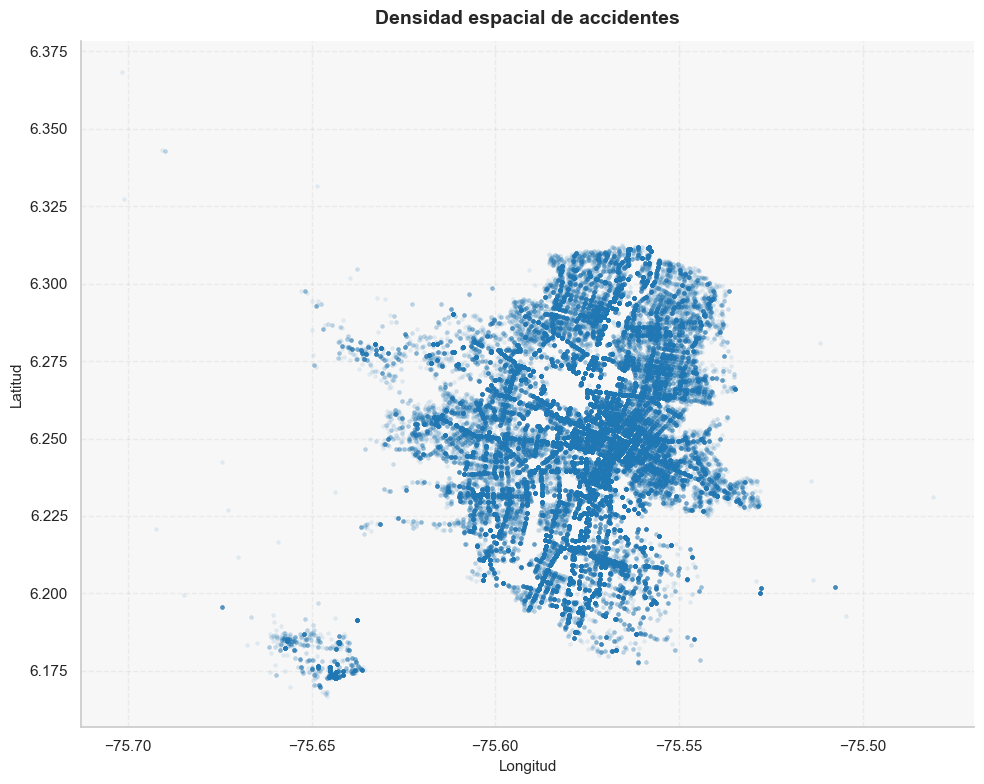

In [10]:
sns.set_theme(style="whitegrid", context="notebook")

fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor("#f7f7f7")

sns.scatterplot(
    data=raw_accidentes,
    x="Lon",
    y="Lat",
    s=8,
    alpha=0.1,
    color="#1f77b4",
    edgecolor=None,
    ax=ax
)

ax.set_title("Densidad espacial de accidentes", fontsize=14, weight="bold", pad=12)
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)

ax.grid(True, linestyle="--", alpha=0.3)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

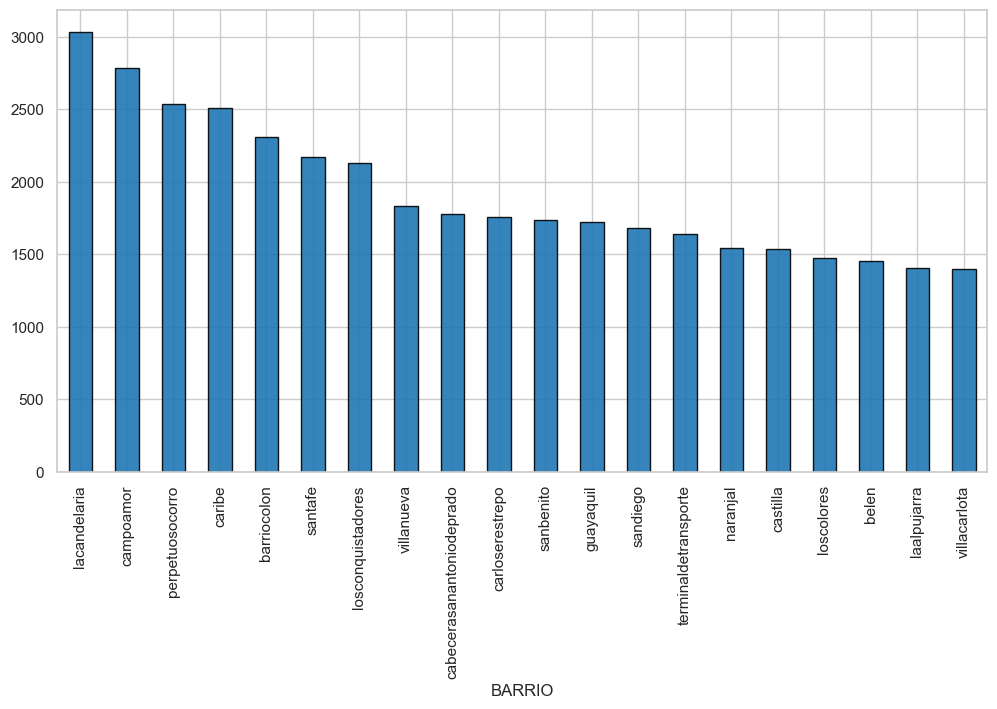

In [11]:
raw_accidentes['BARRIO'].value_counts().iloc[:20].plot(kind='bar', color='#1f77b4', edgecolor='black', alpha=0.9, figsize=(12, 6))
plt.show()

El barrio dónde mas se registran accidentes/hora es en *La Calendaria*, con aproximadamente 3000 accidentes dentro del período de tiempo contemplado

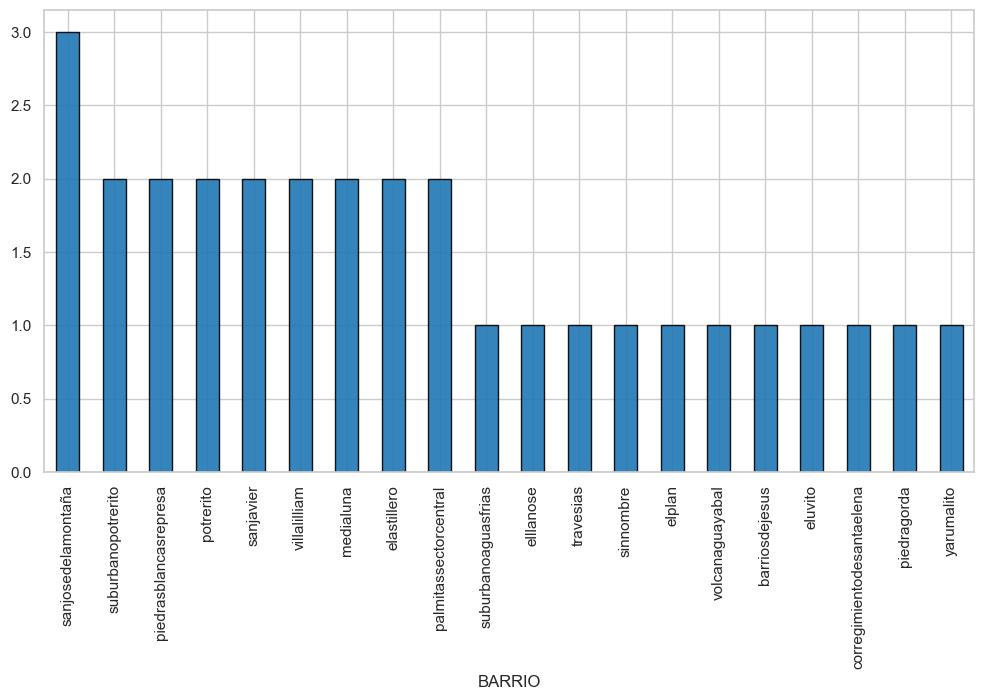

In [12]:
raw_accidentes['BARRIO'].value_counts().iloc[-20:].plot(kind='bar', color='#1f77b4', edgecolor='black', alpha=0.9, figsize=(12, 6))
plt.show()

Existen un conjunto de barrios donde hubo un solo día donde se registraron accidentes en todo el rango de tiempo contemplado, en el gráfico anterior se puede ver.

In [13]:
raw_accidentes['TW'].describe()

count                           125122
mean     2018-07-06 09:11:47.357618688
min                2017-01-01 00:00:00
25%                2017-09-25 16:00:00
50%                2018-07-04 16:30:00
75%                2019-04-17 10:00:00
max                2019-12-31 23:00:00
Name: TW, dtype: object

In [14]:
promedio_mensual_por_barrio = (
    raw_accidentes
    .set_index('TW')
    .groupby('BARRIO')
    .resample('ME', include_groups=False)
    .size()
    .groupby(level=0)
    .mean()
    .sort_values(ascending=False)
)

promedio_mensual_por_barrio.round(2)

BARRIO
lacandelaria             84.36
campoamor                77.36
perpetuosocorro          70.39
caribe                   69.61
barriocolon              64.17
                         ...  
piedrasblancasrepresa     0.17
sanjosedelamontaña        0.17
elvergel                  0.12
villalilliam              0.12
suburbanopotrerito        0.09
Length: 322, dtype: float64

In [15]:
accidentes = pd.read_sql('SELECT * FROM accidentes', con=engine, parse_dates=['TW'])

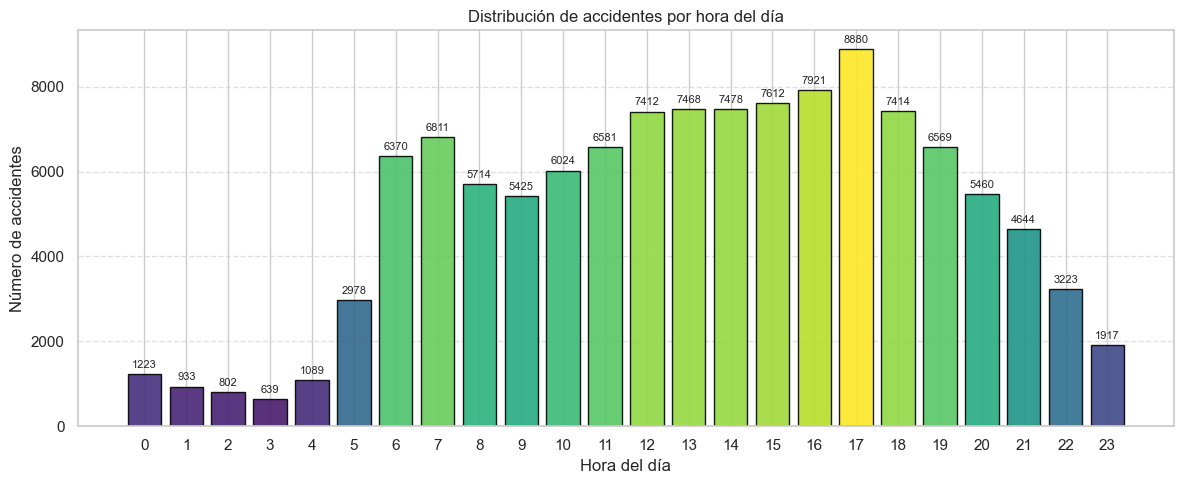

In [16]:
plot_distribucion(
    accidentes,
    columna='Hora',
    titulo='Distribución de accidentes por hora del día',
    xlabel='Hora del día',
    orden=list(range(0, 24))
)

Dado que el datafrme `accidentes` es la fuente natural para la construcción de la variable objetivo, se toma la decisión de crear la columna `es_accidente`

In [17]:
accidentes['es_accidente'] = 1

#### Caracterización del clima

In [18]:
clima = pd.read_sql('SELECT * FROM clima', con=engine, parse_dates=['TW'])

In [19]:
clima.head()

,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0,0.0,16.43,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,1.02,NaN,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,fog,0.0,0.0,15.43,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


In [20]:
clima.shape

(7991780, 15)

Se tienen aproximadamente 8'000.000 de datos en el conjunto de clima.

In [21]:
clima.describe()

,TW,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
count,7991780,7.444379e+06,7.444379e+06,7.991170e+06,7.991170e+06,7.991475e+06,7.990865e+06,7.958987e+06,6.959267e+06,7.983830e+06,7.987500e+06,7.987490e+06
mean,2018-06-27 16:13:29.661927168,4.761443e-01,1.595900e-01,1.965380e+01,1.972720e+01,1.433862e+01,7.343608e-01,1.582619e+00,1.113286e+02,7.224333e-01,2.004863e+00,1.131779e+01
min,2017-01-01 00:00:00,0.000000e+00,0.000000e+00,4.510000e+00,4.510000e+00,2.160000e+00,1.700000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.900000e-02
25%,2017-09-26 12:00:00,0.000000e+00,0.000000e+00,1.683000e+01,1.689000e+01,1.300000e+01,6.400000e-01,8.100000e-01,6.200000e+01,5.200000e-01,0.000000e+00,1.000300e+01
50%,2018-06-25 06:00:00,3.020000e-02,6.000000e-02,1.861000e+01,1.871000e+01,1.442000e+01,7.400000e-01,1.360000e+00,9.000000e+01,7.500000e-01,0.000000e+00,1.000300e+01
75%,2019-03-27 15:00:00,6.058000e-01,2.600000e-01,2.252000e+01,2.260000e+01,1.579000e+01,8.500000e-01,2.090000e+00,1.350000e+02,9.000000e-01,4.000000e+00,1.502000e+01
max,2019-12-31 23:00:00,2.082360e+01,1.000000e+00,3.599000e+01,3.806000e+01,2.404000e+01,1.000000e+00,1.526000e+01,3.590000e+02,1.000000e+00,1.400000e+01,1.609300e+01
std,NaN,8.919243e-01,2.195526e-01,3.753267e+00,3.757843e+00,2.032550e+00,1.554380e-01,1.257904e+00,8.104716e+01,2.079337e-01,2.870109e+00,3.397533e+00


In [22]:
clima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991780 entries, 0 to 7991779
Data columns (total 15 columns):
 #   Column               Dtype         
---  ------               -----         
 0   TW                   datetime64[ns]
 1   BARRIO               object        
 2   summary              object        
 3   icon                 object        
 4   precipIntensity      float64       
 5   precipProbability    float64       
 6   temperature          float64       
 7   apparentTemperature  float64       
 8   dewPoint             float64       
 9   humidity             float64       
 10  windSpeed            float64       
 11  windBearing          float64       
 12  cloudCover           float64       
 13  uvIndex              float64       
 14  visibility           float64       
dtypes: datetime64[ns](1), float64(11), object(3)
memory usage: 914.6+ MB


In [23]:
clima.isna().sum()

TW                           0
BARRIO                       0
summary                 548641
icon                    548641
precipIntensity         547401
precipProbability       547401
temperature                610
apparentTemperature        610
dewPoint                   305
humidity                   915
windSpeed                32793
windBearing            1032513
cloudCover                7950
uvIndex                   4280
visibility                4290
dtype: int64

Se sabe que algunas columnas del dataframe `clima`, tiene nulos. Dentro de las que se destaca `windBearing`, que cuenta con mas de 1 millón de datos **Nulos**, por lo que se puede prescindir de esa columna

In [24]:
clima.drop(['windBearing'], axis=1,inplace=True)

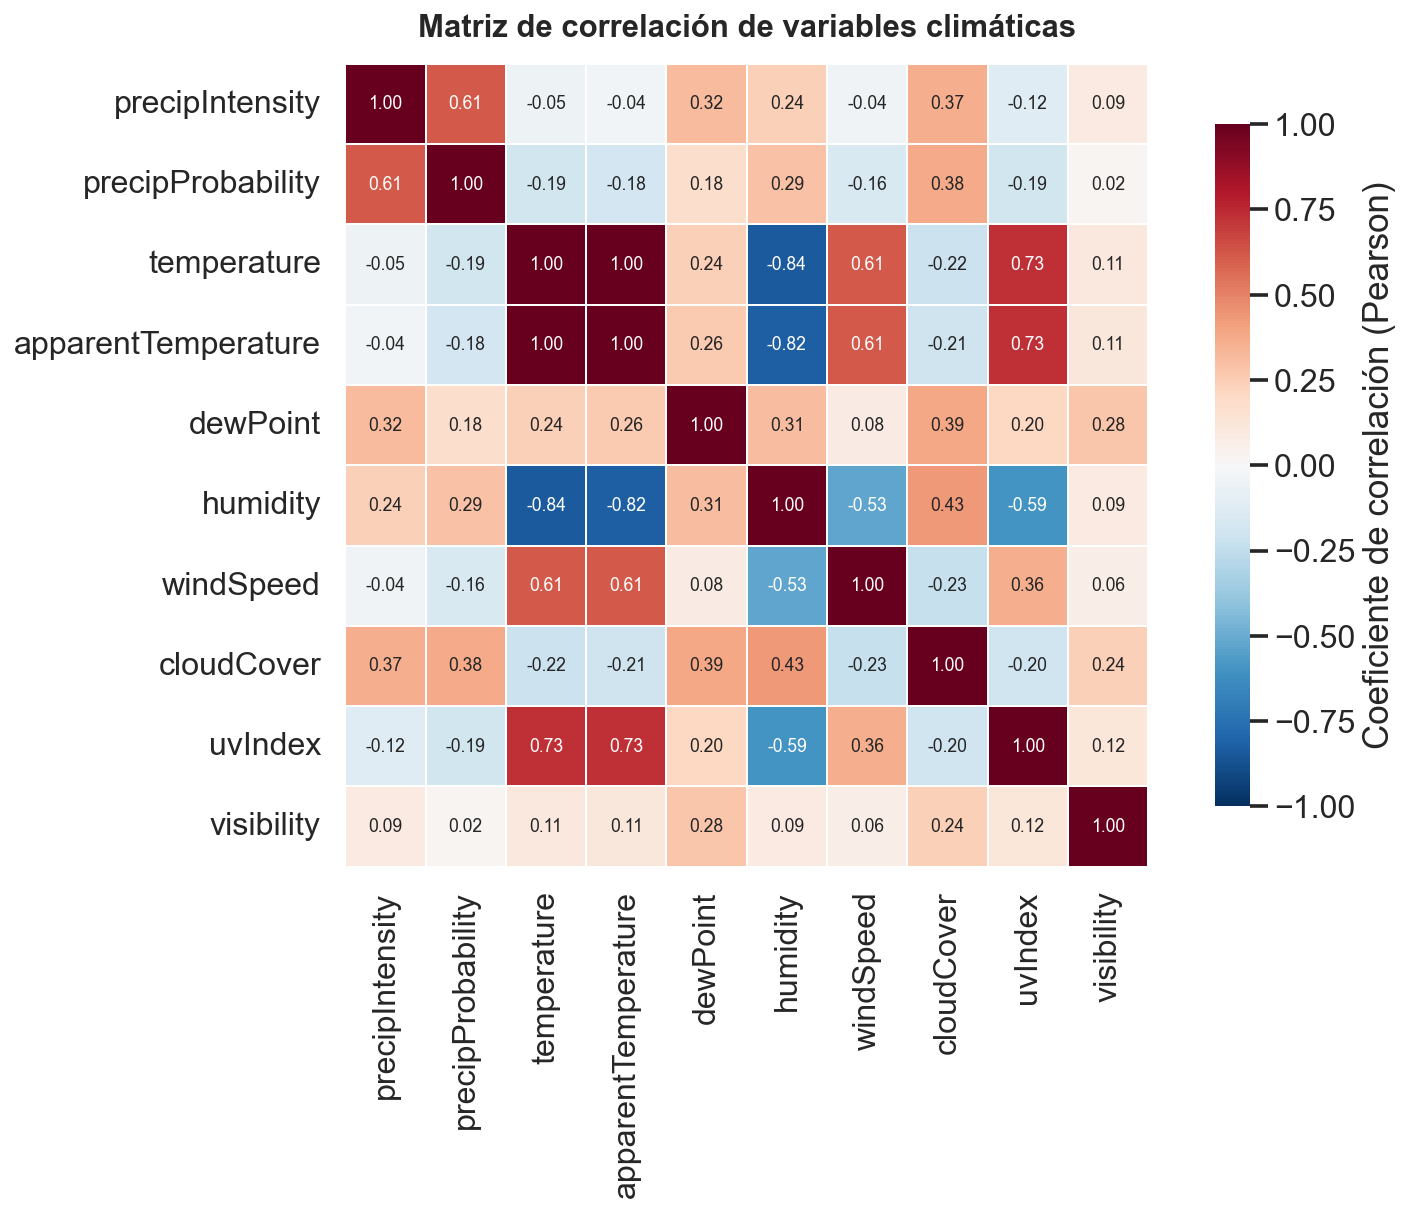

In [25]:
def plot_corr_heatmap(
    df,
    title="Matriz de correlación de variables climáticas",
    figsize=(12, 9),
    dpi=140,
    cmap="RdBu_r",
    annot=True
):
    corr = df.corr(numeric_only=True)
    sns.set_theme(style="white", context="talk")

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    sns.heatmap(
        corr,
        cmap=cmap,
        vmin=-1, vmax=1, center=0,
        annot=annot, fmt=".2f",
        annot_kws={"size": 9},
        linewidths=0.8, linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.85, "label": "Coeficiente de correlación (Pearson)"},
        ax=ax
    )

    ax.set_title(title, fontsize=16, weight="bold", pad=14)
    ax.tick_params(axis="x", rotation=90)
    ax.tick_params(axis="y", rotation=0)

    plt.tight_layout()
    plt.show()
    return corr, fig, ax

clima_corr, fig, ax = plot_corr_heatmap(clima)

De lo anterior, vemos que existen variables que se correlacionan muchos entre si, como por ejemplo:
 - *temperature* -> *apparentTemperature*
 - *temperature* -> *Humedad*
 - *temperature* -> *windSpeed*
 - *temperature* -> *uvIndex*
 - *precipIntensity* -> *precipProbability*

 Dado que tiene fuerte correlación, estas variables se consideran como redudantes por lo que también serán eliminadas del dataser `clima`

In [26]:
clima.drop(['apparentTemperature','precipProbability', 'windSpeed', 'uvIndex','humidity'], axis=1,inplace=True)

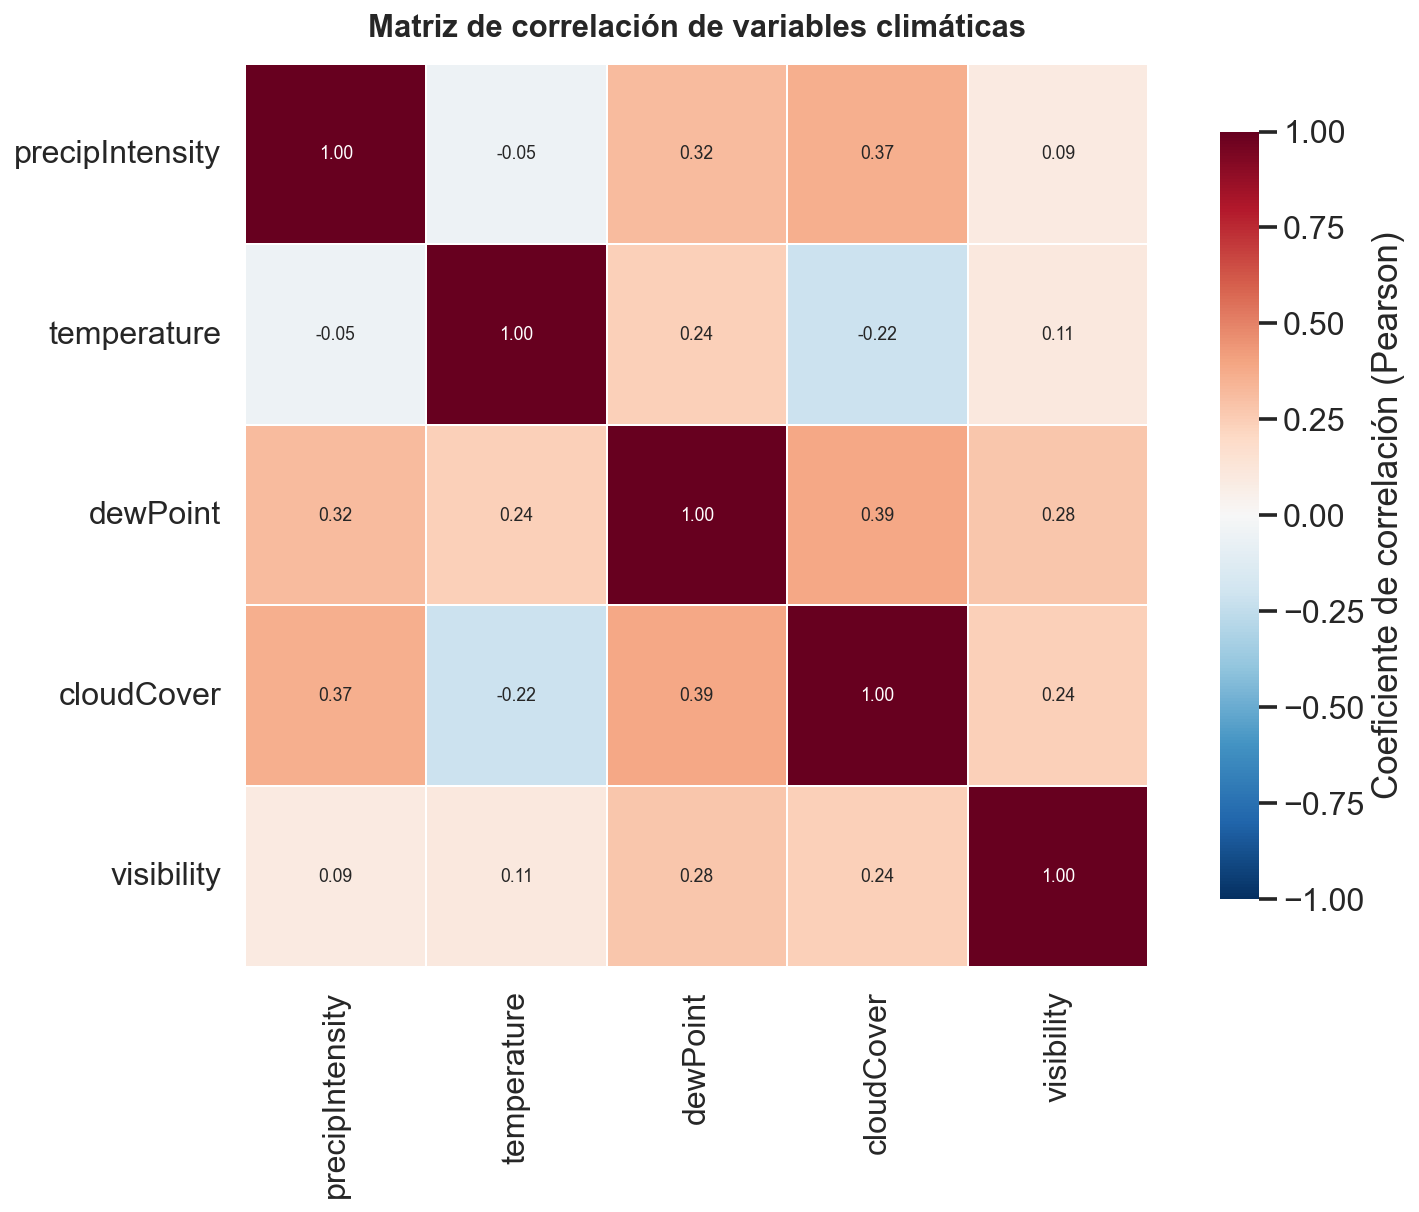

In [27]:
clima_corr, fig, ax = plot_corr_heatmap(clima)

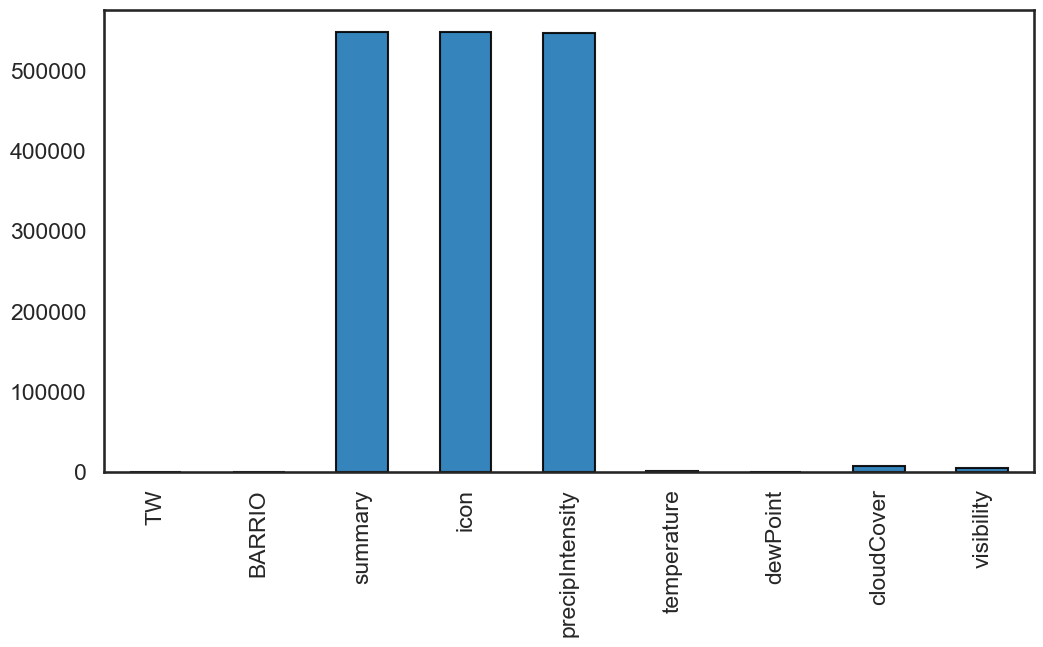

In [28]:
clima.isna().sum() .plot(kind = 'bar', color='#1f77b4', edgecolor='black', alpha=0.9, figsize=(12, 6))
plt.show()

In [29]:
clima[['summary','icon']].drop_duplicates()

,summary,icon
0,Partly Cloudy,partly-cloudy-night
2,Foggy,fog
6,Mostly Cloudy,partly-cloudy-night
7,Mostly Cloudy,partly-cloudy-day
12,Partly Cloudy,partly-cloudy-day
14,Clear,clear-day
33,Overcast,cloudy
43,Clear,clear-night
287,None,None
2326,Drizzle,rain


Analizando las columans `summary` e `icon`, parecen que `icon` es un tipo de agrupacion para `summary`, por lo que también se puede prescidir de esa columna

In [30]:
clima.drop(columns=['summary'], inplace=True)

In [31]:
print(f"Para el conjunto de datos accidentes, hay {accidentes.duplicated(subset=['TW','BARRIO']).sum()} filas duplicadas")
print(f"Para el conjunto de datos clima, hay {clima.duplicated(subset=['TW','BARRIO']).sum()} filas duplicadas")

Para el conjunto de datos accidentes, hay 0 filas duplicadas
Para el conjunto de datos clima, hay 0 filas duplicadas


In [32]:
min_max_dates = clima.groupby('BARRIO').agg({'TW':['min','max']})



In [33]:
min_max_dates.value_counts()

(TW, min)   (TW, max)          
2017-01-01  2019-12-31 23:00:00    295
            2017-12-31 23:00:00      9
            2018-12-31 23:00:00      6
2018-01-01  2018-12-31 23:00:00      6
2019-01-01  2019-12-31 23:00:00      3
Name: count, dtype: int64

Con base a la tabla anterior, no todos los `BARRIOS` tiene un histórico completo

In [34]:
clima.isna().sum()

TW                      0
BARRIO                  0
icon               548641
precipIntensity    547401
temperature           610
dewPoint              305
cloudCover           7950
visibility           4290
dtype: int64

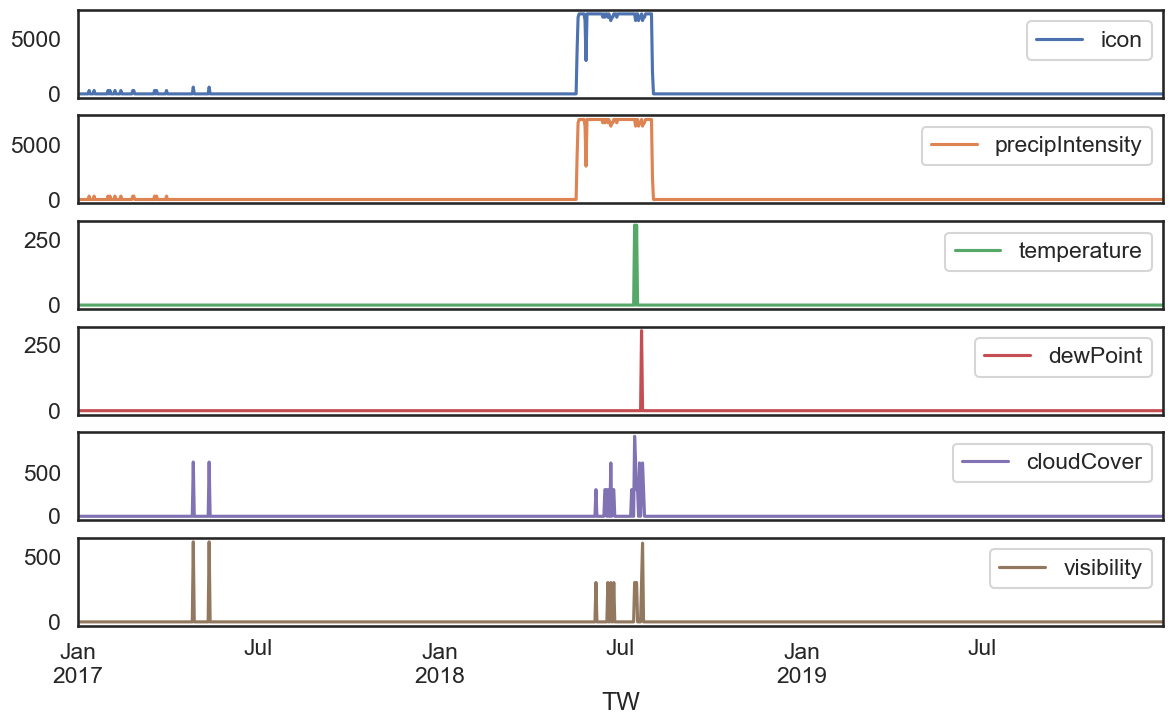

In [35]:
clima.set_index('TW').drop(columns=['BARRIO']).isna().resample('D').sum().plot(subplots=True, figsize=(14, 8))
plt.show()

El fin de la gráfica anterior se puede notar que, para algunos días o meses hay datos nulos, a mitad a principio del año 2017 para la temperatura, y la grán mayoría a mitad del año del 2018.

In [36]:
clima.set_index('TW', inplace=True)

#### Imputación de datos

Para la imputación de datos se comenzará con la columna `icon`, donde imputará el valor de la moda por `BARRIO`

In [37]:
clima['imputed_icon'] = clima.groupby('BARRIO')['icon'].transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]))
clima.drop(columns=['icon'], inplace=True)

In [38]:
for col in clima.select_dtypes(include='number').columns:
    clima[f'imputed_{col}'] = clima.groupby('BARRIO')[col].transform(lambda x: x.interpolate(method='time'))
    clima.drop(columns=[col], inplace=True)
    

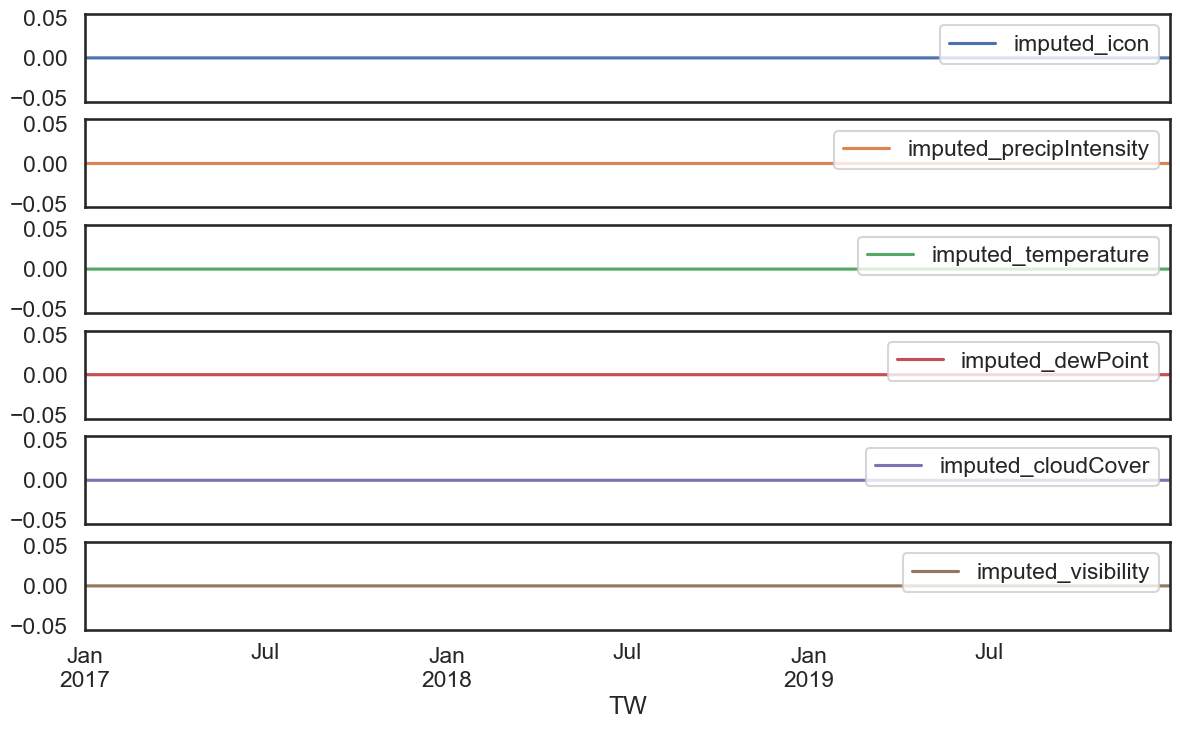

In [39]:
clima.drop(columns=['BARRIO']).isna().resample('D').sum().plot(subplots=True, figsize=(14, 8))
plt.show()

### Inconsistencias

In [40]:
barrios_clima = set(clima['BARRIO'].unique().tolist())
barrios_accidentes = set(accidentes['BARRIO'].unique().tolist())

print(f"Los barrios que se encuentran en clima pero no en accidentes son: {barrios_clima.difference(barrios_accidentes)}")
print(f"Los barrios que se encuentran en accidentes pero no en clima son: {barrios_accidentes.difference(barrios_clima)}")

Los barrios que se encuentran en clima pero no en accidentes son: set()
Los barrios que se encuentran en accidentes pero no en clima son: {'yarumalito', 'suburbanoaguasfrias', 'elastillero'}


In [41]:
print(f"Esto representa en porcentaje al {accidentes['BARRIO'].isin(barrios_accidentes.difference(barrios_clima)).sum()/len(accidentes):.04%}")

Esto representa en porcentaje al 0.0033%


Dado lo anterior, dichos registros pueden ser eliminados del conjunto de datos.

### El tipo de JOIN elegido.

A continuación se hará *join*, del conjuanto de datos de `clima`, ya que es el que posee toda las historia de los barrios. La operación que se hará es un left join, dado que esto hará qeu se conserven todos los datos del conjunto de datos de accidente.

In [42]:
clima.reset_index(inplace=True)

In [43]:
accidentes

,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora,es_accidente
0,2017-07-20 08:00:00,sandiego,6.233985,-75.570146,JUEVES,7,20,8,1
1,2017-06-15 16:00:00,lasacacias,6.238844,-75.600280,JUEVES,6,15,16,1
2,2017-07-02 16:00:00,lopezdemesa,6.285074,-75.584306,DOMINGO,7,2,16,1
3,2017-03-29 18:00:00,losconquistadores,6.239497,-75.583062,MIERCOLES,3,29,18,1
4,2017-07-26 20:00:00,cuartabrigada,6.260463,-75.590193,MIERCOLES,7,26,20,1
...,...,...,...,...,...,...,...,...,...
120582,2019-03-19 07:00:00,lafloresta,6.257358,-75.603532,MARTES,3,19,7,1
120583,2019-02-04 07:00:00,alejandroechavarria,6.239886,-75.550863,LUNES,2,4,7,1
120584,2019-06-18 14:00:00,moscuno1,6.293053,-75.554842,MARTES,6,18,14,1
120585,2019-05-08 18:00:00,boyaca,6.301662,-75.567128,MIERCOLES,5,8,18,1


In [44]:
full_df = clima.merge(accidentes[['TW','BARRIO','es_accidente']], left_on=['TW','BARRIO'], right_on=['TW','BARRIO'], how='left')

In [45]:
def monitor_memory():
    """
    Monitorea y muestra la información de uso de memoria RAM del sistema.
    """
    import psutil
    
    memoria = psutil.virtual_memory()
    
    print(f"Memoria total: {memoria.total / (1024**3):.2f} GB")
    print(f"Memoria disponible: {memoria.available / (1024**3):.2f} GB")
    print(f"Memoria usada: {memoria.used / (1024**3):.2f} GB")
    print(f"Porcentaje de uso: {memoria.percent}%")

# Llamar la función
monitor_memory()

Memoria total: 16.00 GB
Memoria disponible: 3.99 GB
Memoria usada: 5.42 GB
Porcentaje de uso: 75.1%


In [46]:
import gc

# Liberar memoria eliminando dataframes que no se necesitan
del accidentes, clima, clima_corr, fig, ax

# Verificar memoria liberada
monitor_memory()

Memoria total: 16.00 GB
Memoria disponible: 3.94 GB
Memoria usada: 5.46 GB
Porcentaje de uso: 75.4%


In [47]:
full_df['es_accidente'] = full_df['es_accidente'].fillna(0)

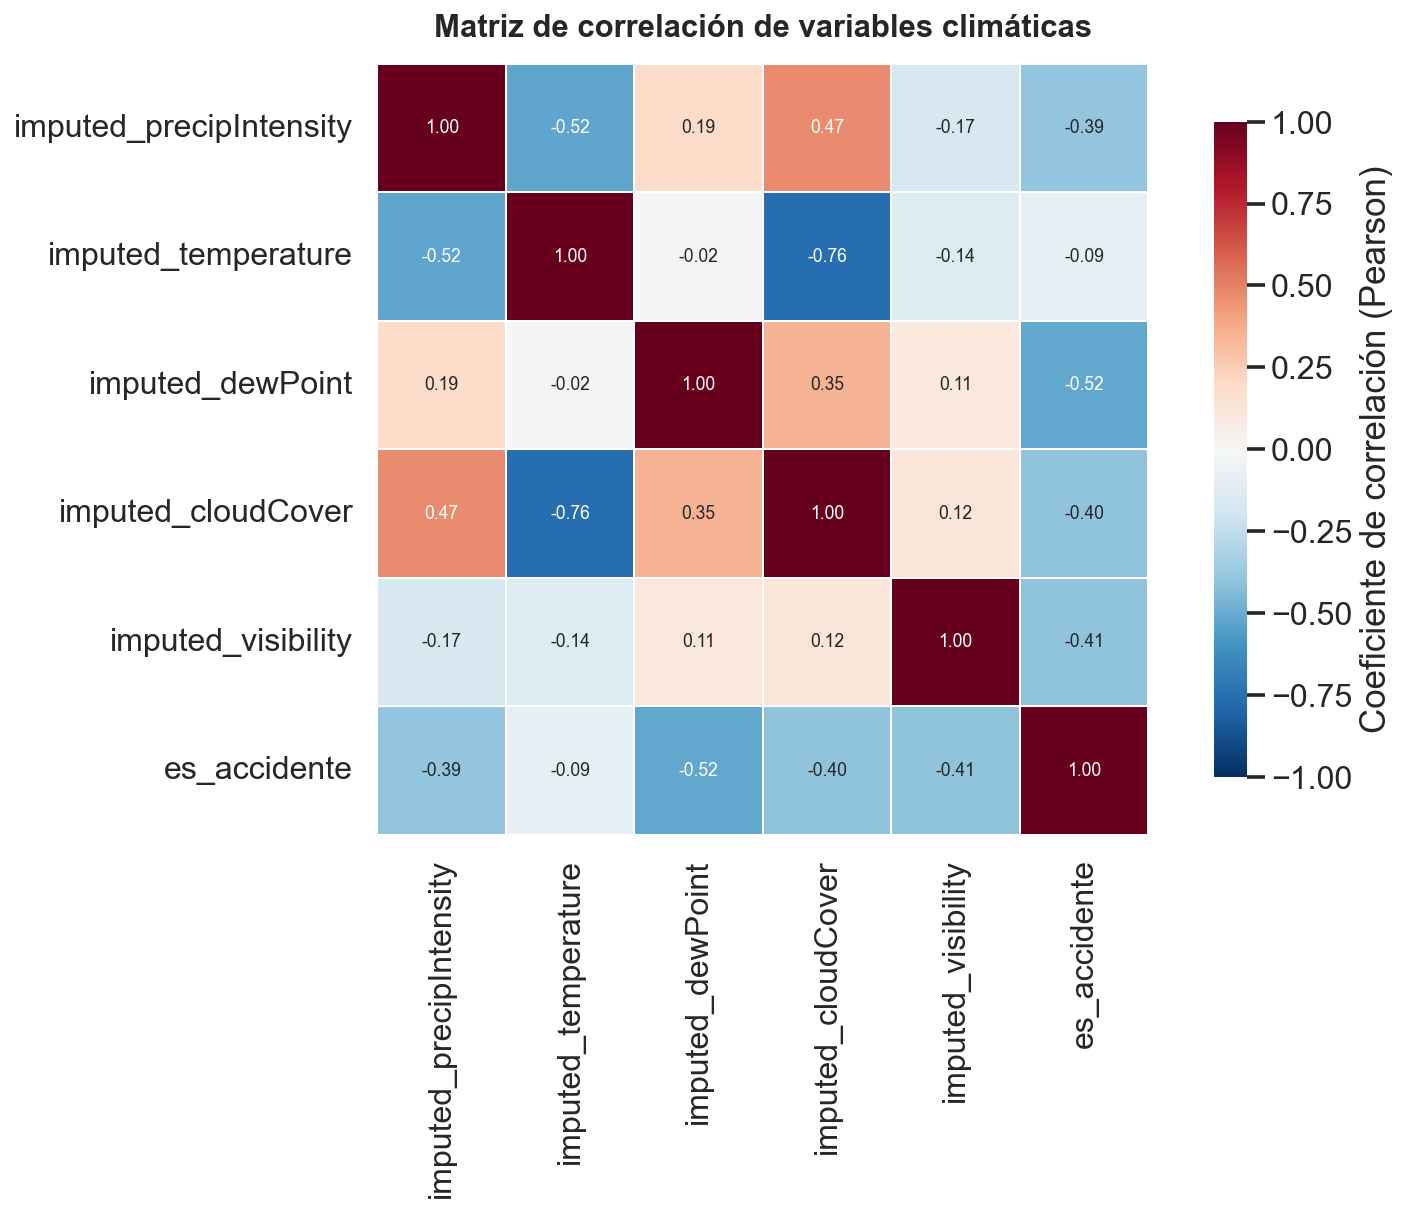

In [48]:
data_corr, fig, ax = plot_corr_heatmap(full_df.select_dtypes(include='number').corr())

Luego de imputar algunos datos, se toma la decision de eliminar la columna `imputed_cloudCover`, ya que tiene alta correlación lineal con `imputed_temperature`

In [49]:
full_df.drop(columns=['imputed_cloudCover'], inplace=True)

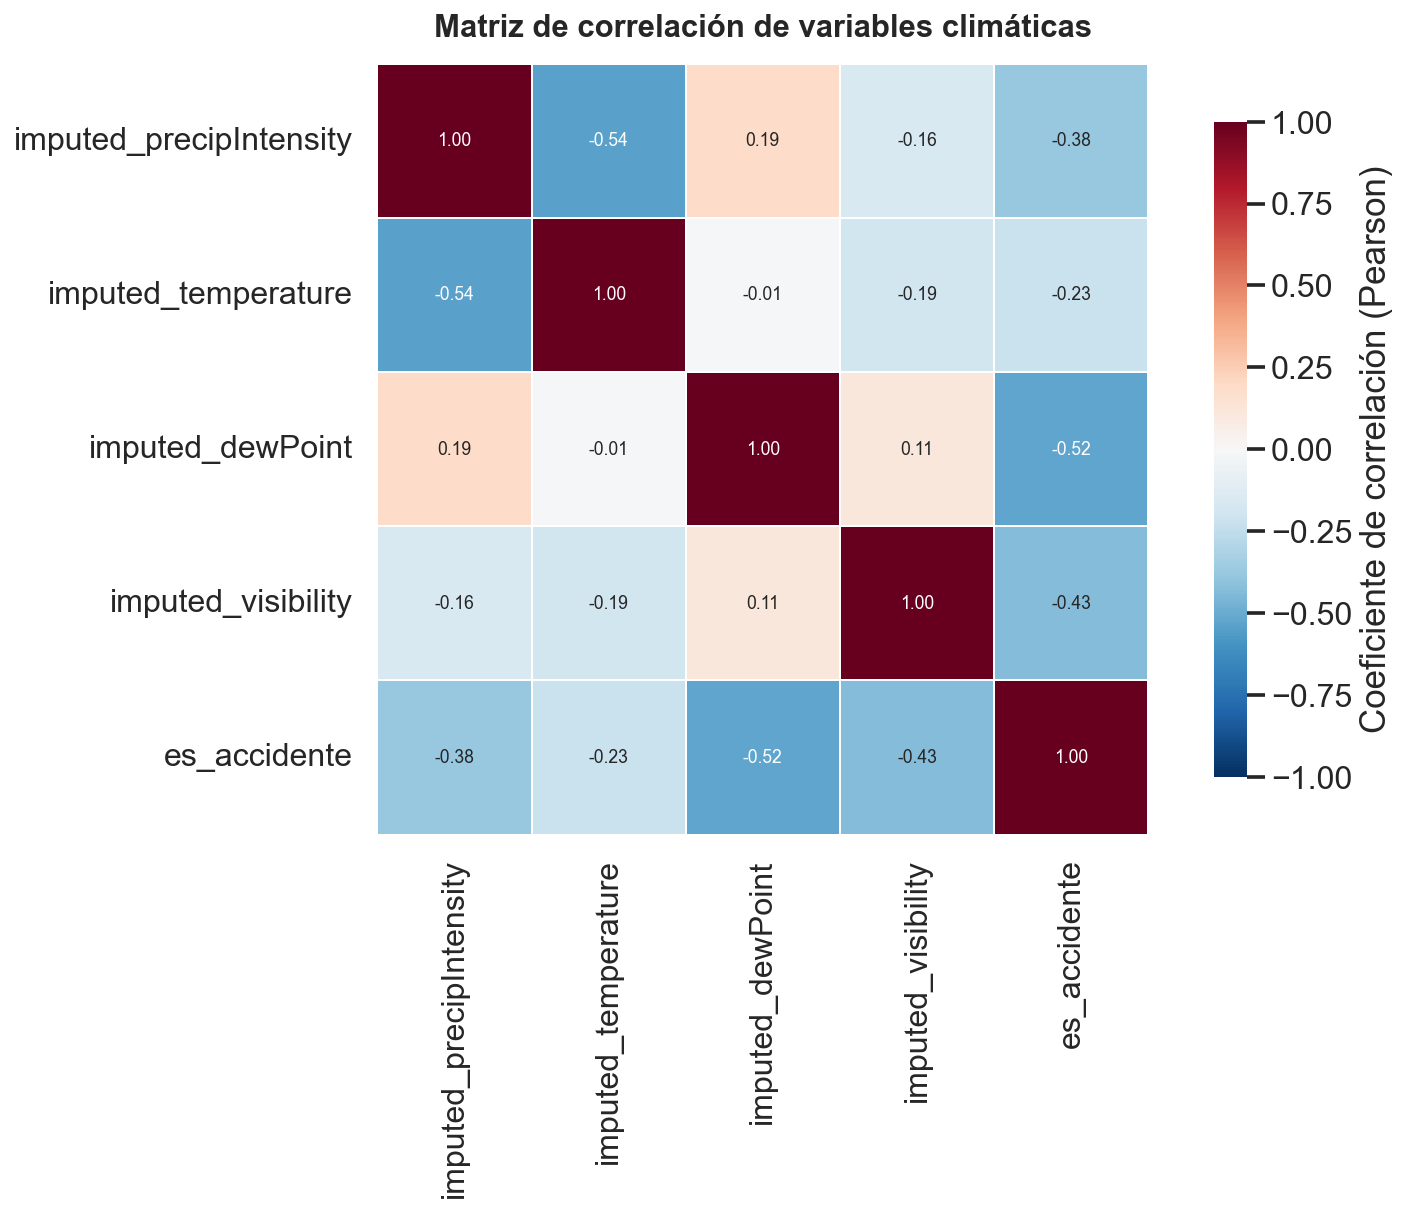

In [50]:
data_corr, fig, ax = plot_corr_heatmap(full_df.select_dtypes(include='number').corr())

Antes de seguir con los análisis y con el feature engineering, vamos a analizar el desbalance que existe en la variable objetivo.

In [51]:
balance = full_df['es_accidente'].value_counts()

In [52]:
print(f"Esto representa el {balance[1]/balance.sum():.2%} del total de filas en el dataset combinado")

Esto representa el 1.51% del total de filas en el dataset combinado


### Feature Engineering

In [53]:
full_df.head()

,TW,BARRIO,imputed_icon,imputed_precipIntensity,imputed_temperature,imputed_dewPoint,imputed_visibility,es_accidente
0,2017-01-01 00:00:00,aguasfrias,partly-cloudy-night,0.0,16.43,14.0,6.004,0.0
1,2017-01-01 01:00:00,aguasfrias,partly-cloudy-night,0.0,16.43,14.0,6.004,0.0
2,2017-01-01 02:00:00,aguasfrias,fog,0.0,15.43,13.0,2.997,0.0
3,2017-01-01 03:00:00,aguasfrias,fog,0.0,15.43,13.0,0.199,0.0
4,2017-01-01 04:00:00,aguasfrias,fog,0.0,15.43,13.0,0.099,0.0


In [54]:

hora = full_df['TW'].dt.hour
mes = full_df['TW'].dt.month
dia_semana = full_df['TW'].dt.weekday
es_fin_de_semana = dia_semana.isin([5, 6])

def crear_variables_ciclicas(df, columna_fecha='TW'):
    hora = df[columna_fecha].dt.hour
    mes = df[columna_fecha].dt.month
    dia_semana = df[columna_fecha].dt.weekday

    df['hora_sin'] = np.sin(2 * np.pi * hora / 24)
    df['hora_cos'] = np.cos(2 * np.pi * hora / 24)

    df['mes_sin'] = np.sin(2 * np.pi * mes / 12)
    df['mes_cos'] = np.cos(2 * np.pi * mes / 12)

    df['dia_semana_sin'] = np.sin(2 * np.pi * dia_semana / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * dia_semana / 7)

    return df

full_df = crear_variables_ciclicas(full_df)

In [55]:

años = full_df['TW'].dt.year.unique()
festivos_colombia = holidays.Colombia(years=años)

full_df['es_festivo'] = full_df['TW'].dt.date.isin(festivos_colombia.keys()).astype(int)
full_df['es_fin_de_semana'] = es_fin_de_semana.astype(int)


In [56]:
full_df.head(20)

,TW,BARRIO,imputed_icon,imputed_precipIntensity,imputed_temperature,imputed_dewPoint,imputed_visibility,es_accidente,hora_sin,hora_cos,mes_sin,mes_cos,dia_semana_sin,dia_semana_cos,es_festivo,es_fin_de_semana
0,2017-01-01 00:00:00,aguasfrias,partly-cloudy-night,0.0,16.43,14.00,6.004,0.0,0.000000e+00,1.000000e+00,0.5,0.866025,-0.781831,0.62349,1,1
1,2017-01-01 01:00:00,aguasfrias,partly-cloudy-night,0.0,16.43,14.00,6.004,0.0,2.588190e-01,9.659258e-01,0.5,0.866025,-0.781831,0.62349,1,1
2,2017-01-01 02:00:00,aguasfrias,fog,0.0,15.43,13.00,2.997,0.0,5.000000e-01,8.660254e-01,0.5,0.866025,-0.781831,0.62349,1,1
3,2017-01-01 03:00:00,aguasfrias,fog,0.0,15.43,13.00,0.199,0.0,7.071068e-01,7.071068e-01,0.5,0.866025,-0.781831,0.62349,1,1
4,2017-01-01 04:00:00,aguasfrias,fog,0.0,15.43,13.00,0.099,0.0,8.660254e-01,5.000000e-01,0.5,0.866025,-0.781831,0.62349,1,1
5,2017-01-01 05:00:00,aguasfrias,fog,0.0,15.43,13.00,0.300,0.0,9.659258e-01,2.588190e-01,0.5,0.866025,-0.781831,0.62349,1,1
6,2017-01-01 06:00:00,aguasfrias,partly-cloudy-night,0.0,16.99,15.91,5.882,0.0,1.000000e+00,6.123234e-17,0.5,0.866025,-0.781831,0.62349,1,1
7,2017-01-01 07:00:00,aguasfrias,partly-cloudy-day,0.0,16.02,15.91,9.724,0.0,9.659258e-01,-2.588190e-01,0.5,0.866025,-0.781831,0.62349,1,1
8,2017-01-01 08:00:00,aguasfrias,partly-cloudy-day,0.0,18.97,15.91,7.811,0.0,8.660254e-01,-5.000000e-01,0.5,0.866025,-0.781831,0.62349,1,1
9,2017-01-01 09:00:00,aguasfrias,partly-cloudy-day,0.0,21.90,16.91,8.005,0.0,7.071068e-01,-7.071068e-01,0.5,0.866025,-0.781831,0.62349,1,1


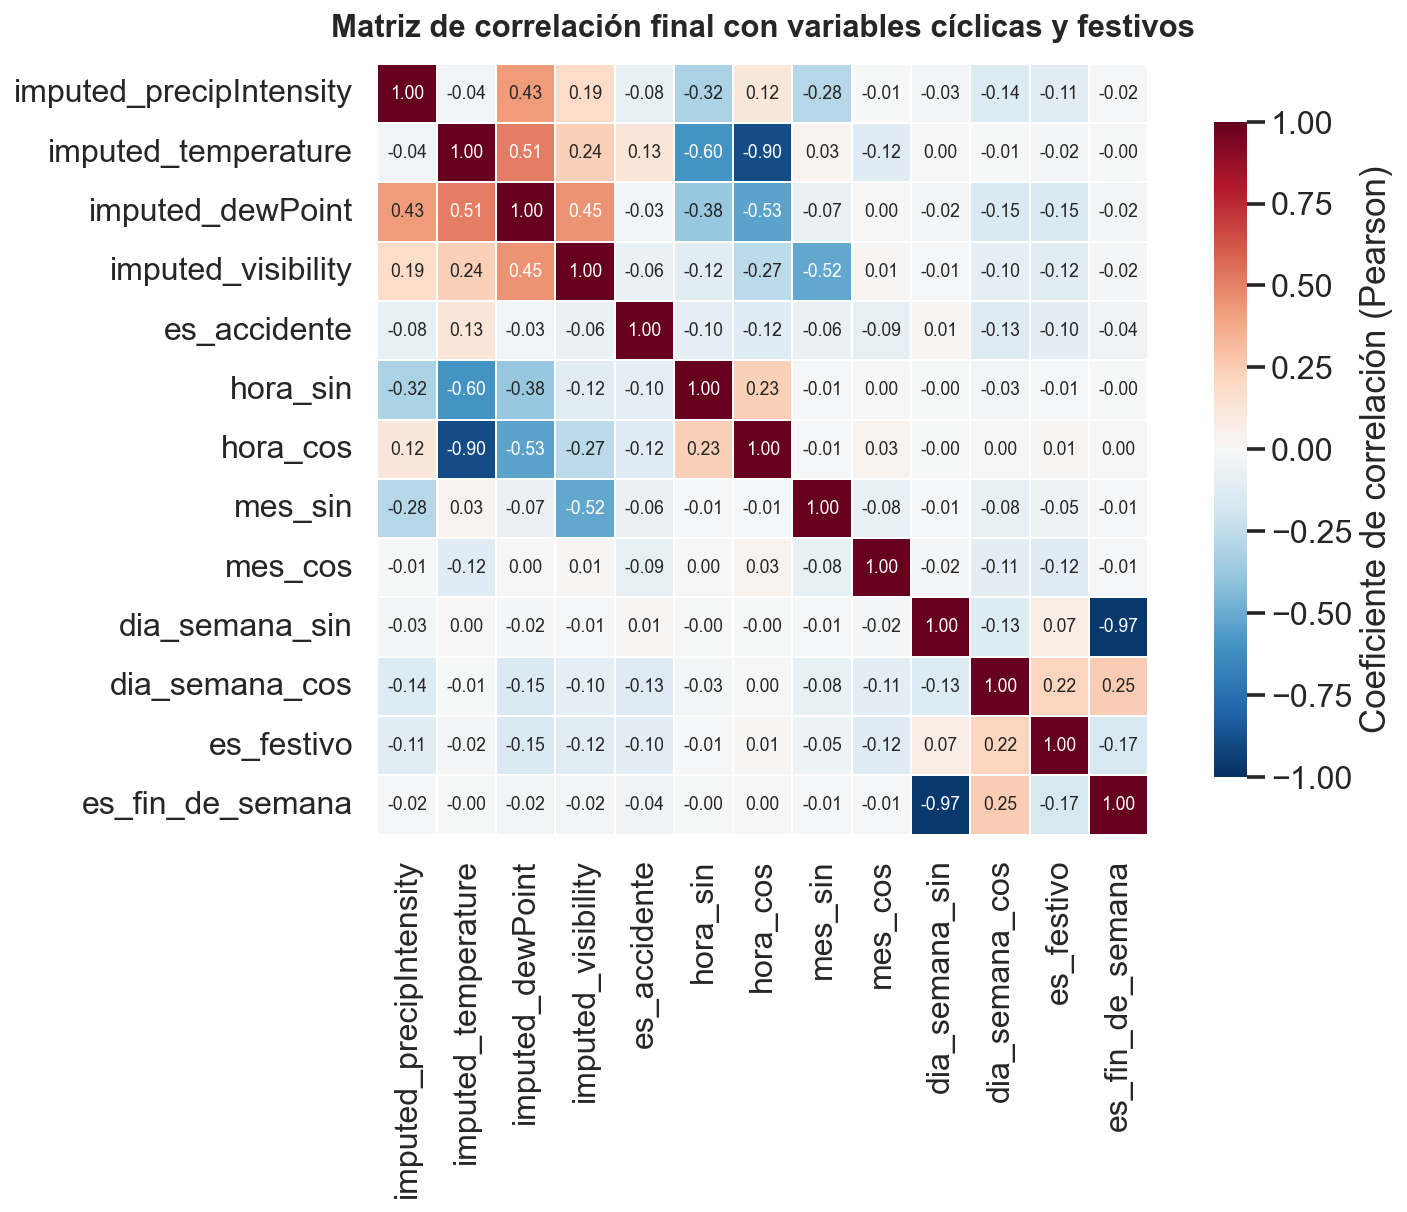

In [57]:
data_corr, fig, ax = plot_corr_heatmap(full_df.select_dtypes(include='number').corr(), title="Matriz de correlación final con variables cíclicas y festivos")

In [58]:
comunas =raw_accidentes[['BARRIO','COMUNA']].drop_duplicates().set_index('BARRIO')

In [59]:
full_df['COMUNA'] = full_df['BARRIO'].map(comunas['COMUNA'].to_dict())

In [60]:
daily = raw_accidentes.set_index('TW').groupby('BARRIO').resample('D', include_groups=False).size()

rolling7_prev = daily.groupby(level=0, group_keys=False).apply(lambda s: s.shift(1).rolling(window=7, min_periods=1).mean(), include_groups=False)\
    .rename('promedio_7d_prev')
rolling7_prev = rolling7_prev.reset_index()

In [61]:
rolling7_prev.head()

,BARRIO,TW,promedio_7d_prev
0,aguasfrias,2017-02-05,NaN
1,aguasfrias,2017-02-06,1.000000
2,aguasfrias,2017-02-07,0.500000
3,aguasfrias,2017-02-08,0.333333
4,aguasfrias,2017-02-09,0.250000


In [62]:
full_df = full_df.merge(rolling7_prev, on=['TW','BARRIO'], how='left')

In [63]:
del raw_accidentes, daily, rolling7_prev, comunas
gc.collect()
monitor_memory()

Memoria total: 16.00 GB
Memoria disponible: 3.36 GB
Memoria usada: 4.80 GB
Porcentaje de uso: 79.0%


### Decodificación de variables Categórcias

In [64]:
# Columnas categóricas a transformar
cat_cols = ['BARRIO', 'COMUNA', 'imputed_icon']
target_col = 'es_accidente'

def mem_mb(df):
    return df.memory_usage(deep=True).sum() / (1024**2)

# =========================
# 1) Frequency Encoding
# =========================
freq_encoded = pd.DataFrame(index=full_df.index)

for c in cat_cols:
    freq_map = full_df[c].value_counts(normalize=True)
    freq_encoded[f'{c}_freq'] = full_df[c].map(freq_map).astype('float32')


full_df_freq = full_df.drop(columns=cat_cols).join(freq_encoded)

print("Shape full_df_freq:", full_df_freq.shape)


Shape full_df_freq: (7991780, 18)


In [65]:
monitor_memory()

Memoria total: 16.00 GB
Memoria disponible: 3.14 GB
Memoria usada: 4.05 GB
Porcentaje de uso: 80.3%


# NOTA IMPORTANTE
---
Lo que sugiera que el conjunto de datos está bastante desbalanceado, adicional a esto la capacidad de computo está limitada, por lo que se opta por hacer un under sampling y a partir de allí, seguir con el ejercicio.

In [66]:
X = full_df.drop(columns=['es_accidente'])
y = full_df['es_accidente']


In [67]:
y.value_counts(normalize=True)

es_accidente
0.0    0.984925
1.0    0.015075
Name: proportion, dtype: float64

In [68]:

del full_df, full_df_freq
gc.collect()
monitor_memory()

Memoria total: 16.00 GB
Memoria disponible: 2.99 GB
Memoria usada: 4.87 GB
Porcentaje de uso: 81.3%


In [70]:
from imblearn.under_sampling import RandomUnderSampler


# 2. Configurar el muestreador
# 'sampling_strategy="auto"' equilibra las clases al 50/50 automáticamente
rus = RandomUnderSampler(sampling_strategy=0.20, random_state=42)

# 3. Aplicar el submuestreo
X_resampled, y_resampled = rus.fit_resample(X, y)

del X, y
gc.collect()
monitor_memory()


Memoria total: 16.00 GB
Memoria disponible: 3.93 GB
Memoria usada: 5.64 GB
Porcentaje de uso: 75.5%


In [71]:
y_resampled.value_counts(normalize=True)

es_accidente
0.0    0.833333
1.0    0.166667
Name: proportion, dtype: float64

# Selección del mejor clasificador para datos desbalanceados

Para este problema, la métrica principal de selección será **PR-AUC** (`Average Precision`), porque penaliza mucho menos el desbalance que la accuracy y es más informativa que ROC-AUC cuando la clase positiva es minoritaria.

Después de elegir el mejor modelo por PR-AUC, también revisaremos `Recall`, `Precision` y `F1` para entender el costo de falsos positivos y falsos negativos.

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Usar solo variables numéricas para evitar problemas con columnas tipo fecha/texto
X = X_resampled.select_dtypes(include=np.number).copy()
y = y_resampled.copy()

# Dar de baja filas con datos faltantes
mask_valid = X.notna().all(axis=1)
X = X.loc[mask_valid].copy()
y = y.loc[mask_valid].copy()

# Split estratificado para evitar fuga de información
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Escalado solo para modelos que lo necesitan
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelos candidatos
models = {
    'LogisticRegression_balanced': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'RandomForest_balanced': RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    if name == 'LogisticRegression_balanced':
        model.fit(X_train_scaled, y_train)
        proba = model.predict_proba(X_test_scaled)[:, 1]
        pred = (proba >= 0.5).astype(int)
    else:
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        pred = (proba >= 0.5).astype(int)

    ap = average_precision_score(y_test, proba)
    precision = precision_score(y_test, pred, zero_division=0)
    recall = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)

    results.append({
        'modelo': name,
        'pr_auc': ap,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })
    predictions[name] = pred
    probabilities[name] = proba

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
results_df

/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/sruiz.gomez/.pyenv/versions/.envML/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encou

,modelo,pr_auc,precision,recall,f1
2,GradientBoosting,0.129326,0.166667,0.004115,0.008032
0,LogisticRegression_balanced,0.116435,0.093403,0.588477,0.161218
1,RandomForest_balanced,0.095130,0.055556,0.004115,0.007663


Resultados ordenados por PR-AUC:
                        modelo    pr_auc  precision    recall        f1
2             GradientBoosting  0.129326   0.166667  0.004115  0.008032
0  LogisticRegression_balanced  0.116435   0.093403  0.588477  0.161218
1        RandomForest_balanced  0.095130   0.055556  0.004115  0.007663

MEJOR MODELO POR PR-AUC: GradientBoosting
PR-AUC: 0.1293
Precision: 0.1667
Recall: 0.0041
F1: 0.0080

Classification report del mejor modelo:
              precision    recall  f1-score   support

No accidente       0.95      1.00      0.97      4806
   Accidente       0.17      0.00      0.01       243

    accuracy                           0.95      5049
   macro avg       0.56      0.50      0.49      5049
weighted avg       0.91      0.95      0.93      5049

Matriz de confusión:
[[4801    5]
 [ 242    1]]


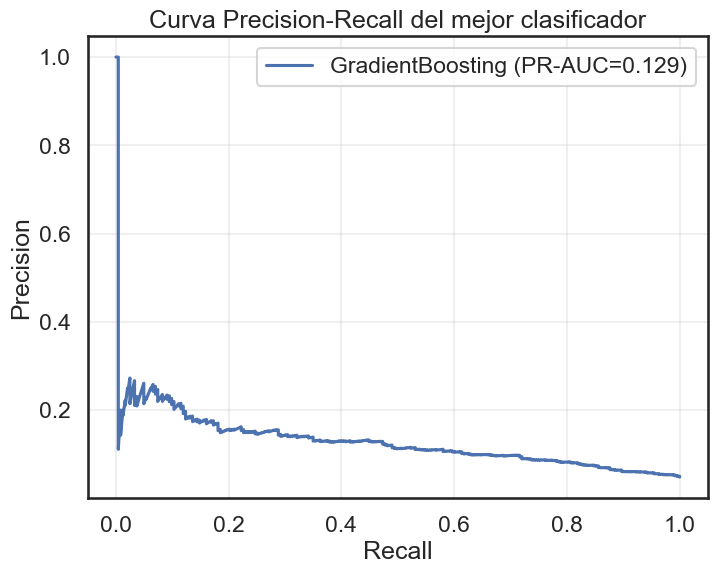


Interpretación recomendada:
- Para datos desbalanceados, elige el modelo con mayor PR-AUC.
- Si el costo de no detectar accidentes es alto, prioriza Recall aunque baje Precision.
- Si quieres menos falsas alarmas, sube el umbral de decisión.


In [75]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

best_idx = results_df['pr_auc'].idxmax()
best_model_name = results_df.loc[best_idx, 'modelo']

print('Resultados ordenados por PR-AUC:')
print(results_df)
print('\n' + '=' * 60)
print(f'MEJOR MODELO POR PR-AUC: {best_model_name}')
print(f"PR-AUC: {results_df.loc[best_idx, 'pr_auc']:.4f}")
print(f"Precision: {results_df.loc[best_idx, 'precision']:.4f}")
print(f"Recall: {results_df.loc[best_idx, 'recall']:.4f}")
print(f"F1: {results_df.loc[best_idx, 'f1']:.4f}")
print('=' * 60)

best_pred = predictions[best_model_name]
best_proba = probabilities[best_model_name]

print('\nClassification report del mejor modelo:')
print(classification_report(y_test, best_pred, target_names=['No accidente', 'Accidente'], zero_division=0))
print('Matriz de confusión:')
print(confusion_matrix(y_test, best_pred))

precision_curve, recall_curve, _ = precision_recall_curve(y_test, best_proba)
pr_auc_best = average_precision_score(y_test, best_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f'{best_model_name} (PR-AUC={pr_auc_best:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall del mejor clasificador')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print('\nInterpretación recomendada:')
print('- Para datos desbalanceados, elige el modelo con mayor PR-AUC.')
print('- Si el costo de no detectar accidentes es alto, prioriza Recall aunque baje Precision.')
print('- Si quieres menos falsas alarmas, sube el umbral de decisión.')


Umbral óptimo para el modelo ganador
Modelo base: GradientBoosting
Umbral elegido por F2: 0.0433
F2: 0.3159
Precision: 0.0976
Recall: 0.7160
F1: 0.1719

Matriz de confusión con el umbral ajustado:
[[3198 1608]
 [  69  174]]

Classification report con el umbral ajustado:
              precision    recall  f1-score   support

No accidente       0.98      0.67      0.79      4806
   Accidente       0.10      0.72      0.17       243

    accuracy                           0.67      5049
   macro avg       0.54      0.69      0.48      5049
weighted avg       0.94      0.67      0.76      5049



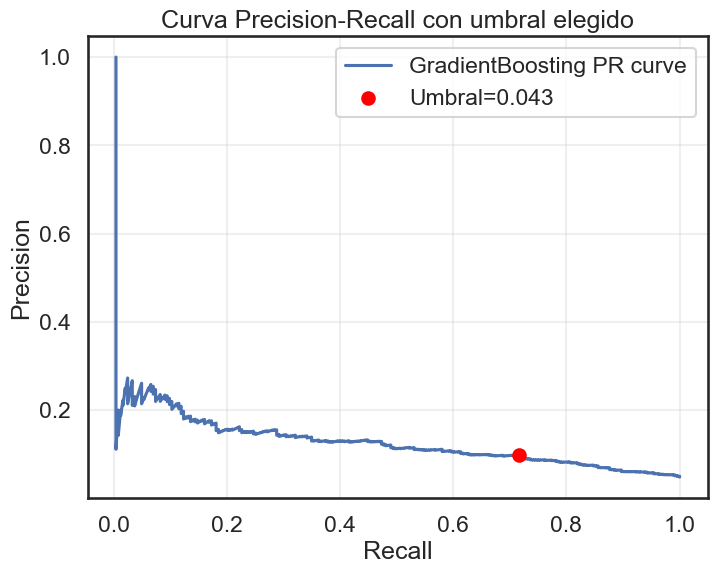

In [76]:
from sklearn.metrics import precision_recall_curve, fbeta_score

# Buscar el umbral que maximiza F2, priorizando recall sobre precision
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, best_proba)

f2_scores = []
for threshold in thresholds:
    pred_thr = (best_proba >= threshold).astype(int)
    f2_scores.append(fbeta_score(y_test, pred_thr, beta=2, zero_division=0))

best_thr_idx = int(np.argmax(f2_scores))
best_threshold = thresholds[best_thr_idx]
best_pred_thr = (best_proba >= best_threshold).astype(int)

print('\nUmbral óptimo para el modelo ganador')
print(f'Modelo base: {best_model_name}')
print(f'Umbral elegido por F2: {best_threshold:.4f}')
print(f'F2: {f2_scores[best_thr_idx]:.4f}')
print(f'Precision: {precision_score(y_test, best_pred_thr, zero_division=0):.4f}')
print(f'Recall: {recall_score(y_test, best_pred_thr, zero_division=0):.4f}')
print(f'F1: {f1_score(y_test, best_pred_thr, zero_division=0):.4f}')
print('\nMatriz de confusión con el umbral ajustado:')
print(confusion_matrix(y_test, best_pred_thr))
print('\nClassification report con el umbral ajustado:')
print(classification_report(y_test, best_pred_thr, target_names=['No accidente', 'Accidente'], zero_division=0))

plt.figure(figsize=(8, 6))
plt.plot(recall_vals[:-1], precision_vals[:-1], label=f'{best_model_name} PR curve')
plt.scatter(
    recall_score(y_test, best_pred_thr),
    precision_score(y_test, best_pred_thr, zero_division=0),
    color='red',
    zorder=5,
    label=f'Umbral={best_threshold:.3f}'
)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall con umbral elegido')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

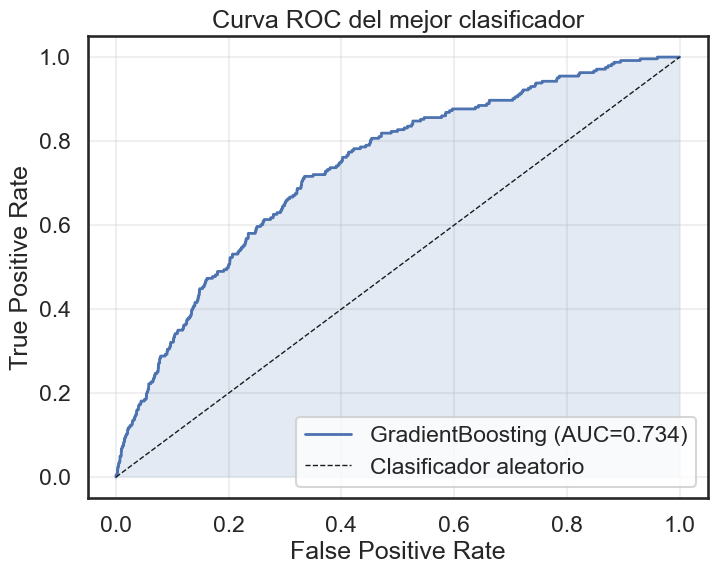

ROC-AUC del modelo GradientBoosting: 0.7338


In [77]:
from sklearn.metrics import roc_curve, roc_auc_score

# Curva ROC del modelo ganador
fpr, tpr, _ = roc_curve(y_test, best_proba)
roc_auc = roc_auc_score(y_test, best_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'{best_model_name} (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.fill_between(fpr, tpr, alpha=0.15)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC del mejor clasificador')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f'ROC-AUC del modelo {best_model_name}: {roc_auc:.4f}')

## Interpretación de la matriz de confusión y métricas derivadas

La matriz de confusión resume cuatro resultados posibles:
- **TN**: no accidente bien clasificado.
- **FP**: no accidente clasificado como accidente.
- **FN**: accidente clasificado como no accidente.
- **TP**: accidente bien clasificado.

A partir de ella se interpretan estas métricas:
- **Accuracy** = proporción total de aciertos. En datos desbalanceados puede ser engañosa, porque la clase mayoritaria domina el cálculo.
- **Precision** = de todo lo que el modelo predijo como accidente, qué proporción sí era accidente. Se interpreta así porque mide el costo de falsas alarmas.
- **Recall** = de todos los accidentes reales, qué proporción detectó el modelo. Se interpreta así porque mide cuánto se están escapando los positivos reales.
- **F1-score** = balance entre `Precision` y `Recall`. Se usa cuando se quiere una medida única que penalice ambos errores.
- **Specificity** = de todos los no accidentes reales, qué proporción identificó bien el modelo como no accidente. Se interpreta así porque refleja cuántos falsos positivos se evitan.
- **NPV** = de todo lo predicho como no accidente, qué proporción era realmente no accidente. Sirve para medir confianza en las predicciones negativas.

En un problema desbalanceado, **`Recall` y `F1` suelen ser más relevantes que `Accuracy`**, y si la prioridad es detectar accidentes, `Recall` pesa más que `Precision`.

Con el umbral ajustado del último modelo, la matriz de confusión es:

```python
[[3198, 1608],
 [  69,  174]]
```

In [78]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

cm = confusion_matrix(y_test, best_pred_thr)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, best_pred_thr)
precision_v = precision_score(y_test, best_pred_thr, zero_division=0)
recall_v = recall_score(y_test, best_pred_thr, zero_division=0)
f1_v = f1_score(y_test, best_pred_thr, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

print('Matriz de confusión:')
print(cm)
print('\nMétricas derivadas:')
print(f'Accuracy   : {accuracy:.4f}')
print(f'Precision  : {precision_v:.4f}')
print(f'Recall     : {recall_v:.4f}')
print(f'F1-score   : {f1_v:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'NPV        : {npv:.4f}')

print('\nInterpretación corta:')
print(f'- TN={tn}: casos correctos de no accidente.')
print(f'- FP={fp}: falsas alarmas.')
print(f'- FN={fn}: accidentes perdidos por el modelo.')
print(f'- TP={tp}: accidentes correctamente detectados.')
print('- En este problema, FN es especialmente crítico porque significa accidentes no detectados.')
print('- Accuracy puede verse alta por el desbalance, pero Recall y F1 muestran mejor el desempeño real.')

Matriz de confusión:
[[3198 1608]
 [  69  174]]

Métricas derivadas:
Accuracy   : 0.6679
Precision  : 0.0976
Recall     : 0.7160
F1-score   : 0.1719
Specificity: 0.6654
NPV        : 0.9789

Interpretación corta:
- TN=3198: casos correctos de no accidente.
- FP=1608: falsas alarmas.
- FN=69: accidentes perdidos por el modelo.
- TP=174: accidentes correctamente detectados.
- En este problema, FN es especialmente crítico porque significa accidentes no detectados.
- Accuracy puede verse alta por el desbalance, pero Recall y F1 muestran mejor el desempeño real.


Umbral seleccionado: 0.0520
Precision mínima exigida: 0.10
Precision lograda: 0.1017
Recall logrado: 0.6132
F2 logrado: 0.3057

Matriz de confusión con el nuevo umbral:
[[3490 1316]
 [  94  149]]


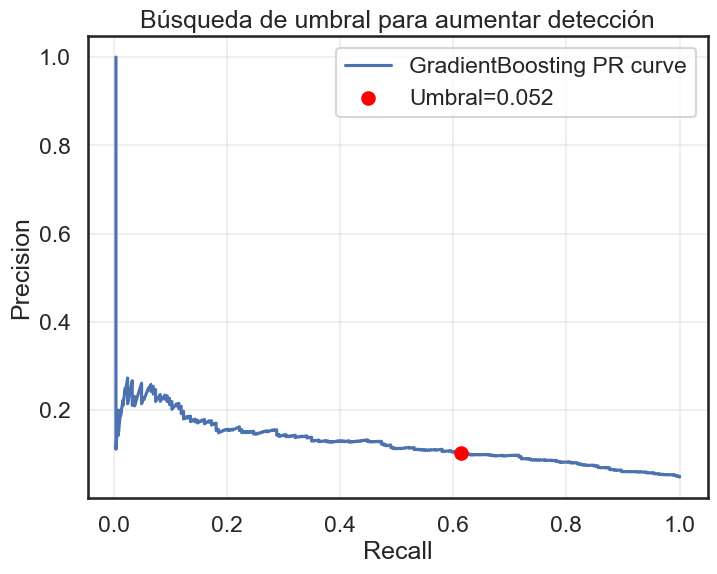

In [79]:
from sklearn.metrics import precision_score, recall_score, fbeta_score, confusion_matrix

# Ajusta este valor según cuánta precisión mínima quieres conservar
precision_minima = 0.10

# Buscar el umbral que maximiza el recall manteniendo precision >= precision_minima
candidate_thresholds = np.linspace(0.0, 1.0, 501)
mejores = []

for thr in candidate_thresholds:
    y_pred_thr = (best_proba >= thr).astype(int)
    p = precision_score(y_test, y_pred_thr, zero_division=0)
    r = recall_score(y_test, y_pred_thr, zero_division=0)
    f2 = fbeta_score(y_test, y_pred_thr, beta=2, zero_division=0)
    if p >= precision_minima:
        mejores.append((thr, p, r, f2))

if mejores:
    mejor_thr, mejor_p, mejor_r, mejor_f2 = max(mejores, key=lambda x: (x[2], x[3]))
    y_pred_mejor_thr = (best_proba >= mejor_thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_pred_mejor_thr)

    print(f'Umbral seleccionado: {mejor_thr:.4f}')
    print(f'Precision mínima exigida: {precision_minima:.2f}')
    print(f'Precision lograda: {mejor_p:.4f}')
    print(f'Recall logrado: {mejor_r:.4f}')
    print(f'F2 logrado: {mejor_f2:.4f}')
    print('\nMatriz de confusión con el nuevo umbral:')
    print(cm_thr)
else:
    print(f'No se encontró un umbral con precision >= {precision_minima:.2f}.')
    print('Prueba bajando la precisión mínima o usando un modelo con más capacidad de separación.')

plt.figure(figsize=(8, 6))
plt.plot(recall_vals[:-1], precision_vals[:-1], label=f'{best_model_name} PR curve')
if mejores:
    plt.scatter(mejor_r, mejor_p, color='red', zorder=5, label=f'Umbral={mejor_thr:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Búsqueda de umbral para aumentar detección')
plt.grid(alpha=0.3)
plt.legend()
plt.show()